# An Investigation Into Computational Fluid Dynamics (CFD)

## Zackary Schnitzer
### 16 April 2024

It is no exageration to say that computational fluid dynamics is **hard**. However, to reference a blog post which has now only remains in my memory, "bad CFD is easy, good CFD is hard."  Ultimately, my goal was to spend the semester learning as much as I could about CFD with the intent to make a simultation that just barely reaches across the line from bad CFD to good CFD, but as highlighted by the unattributed blogger, that was not such an easy task.

Yet, with the difficulty of good CFD comes great rewards, allowing individuals to test designs of objects without the need to physically create and test the designs. Highly used among engineers, CFD software allows for a more efficient design and testing process, where the effects of changes can be determined before the modification is ever made.

Yet, before even writing the first lines of code there are a multitude of decisions that must be made about how the CFD simulation is going to function, all of which change how the program should be written. I will now briefly run through the set of decisions made for this simulation in particular
## Decisions....Decisions... Decisions...

### Visual Focussed or Number Focussed?

There are two main approaches to a simulation, and this is possibly the decision that most influences how the program will take shape. With a visual focus, all that one considers is what a fluid flow would look like if smoke were moving around an object. This created beautiful graphics, but does not provide any useful measurements about the flow. It does, however have the advantage of not needing to numerically solve a set of differential equations.

A number focussed simulation does not produce the most pleasing graphics (that is not to say they are completely boring however) but does provide measurements about a fluid flow without having to conduct the experiment in real life--well, at least a good program is capable of doing this. In accomplishing this, it is nearly always necessary to solve a set of differential equations to obtain a solution.

I have decided to take a number focussed approach for this project.

### Eulerian or Lagrangian?

These two approaches determine how a program goes about calculating information about the fluid flow.

A Lagrangian approach follows a bunch of particles in a fluid, tracking their paths, and determining information about the flow from the behavior of these distinct streams.

An Eulerian approach does not place any focus on particles, but rather it slices the entire space into a grid, and considers the flow velocity and pressure at each individual grid point to calculate information about the flow as a whole. An Eulerian simulation lends itself to numerically solving a form of the Navier-Stokes equations.

My program uses an Eulerian approach, as I wanted to learn how to numerically solve hard differential equations.

### Compressible or Incompressible? Viscous or Inviscid?

Having narrowed the simulation down to a number focussed, Eulerian simulation, I have forced myself to solve a set of differential equations, but the equations that must be solved rely on what type of fluid the simulation is modelling. In the simplest case, a flow can be represented as incompressible and inviscid, reducing the equations to relatively simple conservation of mass and momentum conditions. When considering compressible flow, one must allow the density of the fluid to change with time, complicating the conservation equations. Similarly, when considering viscous flow, one must modify the conservation of momentum equations to account for the shear stress of the fluid (essentially the fluid pulling on itself). I found that it is fairly simple to account for viscous fluid by simply adding an extra term to the momentum equations, but that it was wildly more difficult (and mostly pointless) to consider compressible flow.

As such, my program considers incompressible viscous flow.


## Building up to the Simulation

As mentioned in the previous section, my choices regarding my simulation force me down the path of numerically solving a set of differential equations; more specifically solving a set of coupled nonlinear partial differential equations. Prior to this project, my experience in numerical methods started and ended with Euler's method, an effective method for simple equations and initial value problems, but not applicible to fluid dynamics equations and boundary value problems. I clearly needed more powerful methods, and that meant experimenting with a multitude of differential equations of various complexity.

Initial research led me to an incredibly useful paper by Rajesh Bhaskaran and Lance Collins, outlining an intro to CFD and led me on the right track with this project.

### The Finite-Difference Method

Bhaskaran and Collins paper highlighted the finite difference method for solving differential equations, which functions by slicing a space into finite chunks, then converting the differential equations into linear equations, the solutions to which approximate the solution to the differential equations. 

Obtaining the finite difference equations for linear differential equations of any order is rather simple, just replacing the derivative with its linear approximation. For instance, consider solving the equation $\frac{du}{dx}+u=0$ with $x$ on the range $[0,1]$ and $u(0)=0$, approximating with 5 grid points labeled with $i=1,2,3,4,5$ equally spaced by $\Delta x = 0.25$.

The derivative at grid point $i$ can be linearly approximated as $\frac{du}{dx}=\frac{u_{i}-u_{i-1}}{\Delta x}$ making the differential equation approximately equal to $\frac{u_{i}-u_{i-1}}{\Delta x}+u_{i}=0$. Written in another form, the equation becomes$-u_{i-1}+ (1-\Delta x)u_{i}=0$

Writing these equations for all 5 points grid points, considering the boundary conditions, gives the following system of linear equations: $$\begin{cases} u_{1}=0 \\ -u_{1}+ (1-\Delta x)u_{2}=0 \\ -u_{2}+ (1-\Delta x)u_{3}=0 \\ -u_{3}+ (1-\Delta x)u_{4}=0 \\ -u_{4}+ (1-\Delta x)u_{5}=0\end{cases}$$

All that is left is to solve the set of equations for the values of $u$ at each grid point, and the differential equation is numerically solved!

To accomplish this, I wrote a program that generates a matrix based on the set of equations, inverts it, and multiplies the inverted matrix by a zero vector, solving the set of equations. 

Running the following program numerically solves this equation with the method described above and graphs the solution it against the analytical solution

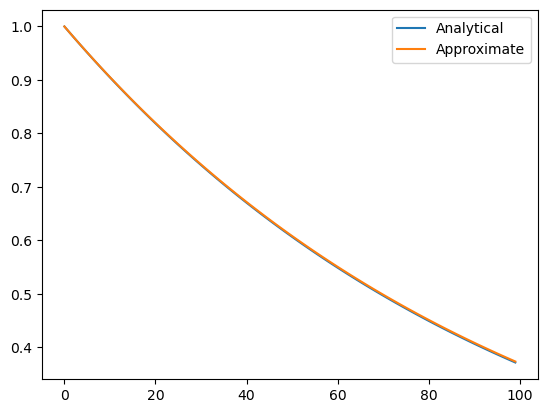

In [1]:
%run FiniteDifferenceAlgorithm.py
#Note: the x axis is representing the value of i, not the actual x value
#the actual x range is still from [0,1]

### Dealing with Non-Linearity

While the finite difference method works well for linear differential equations, it runs into trouble very quickly when non-linearity enters the picture, as the system of algebraic equations that result are non-linear themselves, and, as such, much more difficult to solve. However, there are methods which exist to approximate solutions through an itterative process, such as Newtons method. I briefly tested out one method, which makes use of guess values, and through a series of itterations, converges to the analytical solution of the differential equation. I will not go into much detail about this process for the sake of brevity, but the following file and plot demonstrates the how, through many itterations, a solution results. Also, from this point on the runtime of the file will be printed. Note how it increase dramatically as more complex methods are used.

Time elapsed 0.0354 seconds


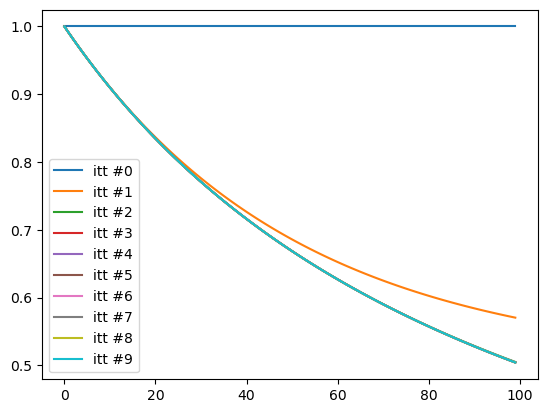

In [2]:
%run FiniteDifferenceTestNL.py

### Moving Forward in Time (and adding dimensions) with the Wave Equation

Continuing with the gradual build in complexity, I now turned by attention to the wave equation, chosen because it forces me to include time in the calculations, and a correct solution would be easily verifiable due to it propogating like a wave. It also allows for me to attempt to extend the simulation into two dimensions. It is in this stage where many problems began to arise, of which I will mention as they appear.

The wave equation in its most general form can be written as: $$\frac{\partial^2u}{\partial t^2} = c^2\nabla^2u$$

For one dimension this reduces to $$\frac{\partial^2u}{\partial t^2} = c^2\frac{\partial u}{\partial t}$$

Applying the finite difference method to this equation involves a two small steps in the x (spatial) direction (one to each side), as well as two steps back in the time direction (two steps are needed since the equation is second order in time). We are essentially considering time as an additional dimension. Changing the derivatives to finite difference approximations, the values of u at previous time steps can be used to solve for the value of u at the next time step. 

The code runs like this:
1. Create and invert the matrix that will solve the finite difference equations for the next time step (this does not change)
2. Generate a column vector using the values of u at an x value for the two previous time steps (this does change and is created every time step)
3. Multiply the column vector by that matrix
4. The solution is the values of u at the next step in time
5. Repeat 2-4 for 3000 itterations.

The following program follows the above steps, solving the wave equation for one dimension, with the boundary condition of $u=0$ at the ends.

In [5]:
#Note the runtime is starting to get quite large already
%run FiniteDifferenceWaveEq.py

#The following code displays the animations
import ipywidgets as widgets
display(widgets.HTML('<img src="FiniteDifferenceWaveEq.gif">'))

Time Elapsed: 1.0401 seconds


HTML(value='<img src="FiniteDifferenceWaveEq.gif">')

Obtaining this result was nothing short of a triumph, and my confidence was high, however I was wary of the runtime rapidly growing. For the above program, the matrix used to solve the equations was 500 x 500, and in general for $n$ points in space, the matrix would be $n$ x $n$, a worrying point for the extension to 2 dimensions. Yet the saving grave for the wave equation is that it is linear, meaning the matrix only has to be generated and inverted once, so taking a runtime hit upfront would ultimately pay off. This is not the case for nonlinear equations though, but that is a problem which I pushed off for the time being and moved on to the 2D case.

#### 2D Extension

Extending to two dimensions was more of a math issue than a coding issue. Notably I had to find a way to fit two dimensions into a single column vector and create a matrix which would solve for the values of $u$ on the whole two dimensional sheet at the same time. In doing this, I accidentally reinvented tensors which was a delightful outcome. Unfortunately, I will not go into the detail of the math, as all that is necessarilly important is to know that the column vector contains the $u$ values for every point in a 50 x 50 grid, meaning the matrix that had to be inverted was 2500 x 2500. 

The following program does this calculation and results in a nice animation of a vibrating membrane.

In [8]:
#Oh wow...that runtime is going up quick! (No need to run if you just want to see the animation)
%run FiniteDifferenceWaveEq2D.py

Time Elapsed: 15.3957 seconds


In [9]:
#The following code displays the animation
display(widgets.HTML('<img src="FiniteDifferenceWaveEq2D.gif">'))

HTML(value='<img src="FiniteDifferenceWaveEq2D.gif">')

### Problems...Problems.....More Problems...

It is at this point where I put the project aside for about two weeks. Having made so much progress in such a short amount of time, I was comfortable that once I found another nugget of good research, the progress would come back, once again at a rapid pace. However, at this time I was stuck and facing a multitude of problems.

First, this method is only scalable for linear equations in very few dimensions, where a relatively small matrix can be created and inverted only once. For non-linear equations, a matrix has to be made and inverted every time; this is fine for a small number of points, but rapidly slows down the process when scaled up to the order of thousands. It should be mentioned that most of the runtime of the 2D wave equation simulation above was spent just creating and inverting the matrix. For a non-linear equation that inversion would have to happen for each of the 1000 itterations, quickly pushing the runtime into the hours. On top of it, solving the fluid flow equations involves solving for 3 variables at once, increasing the size of the matrix by a factor of 9, adding insult to injury.

Second, trying to deal with non-linearity the way outlined earlier simply does not work. Regardless of the initial conditions and the parameters used, the solution diverges; the error in the approximations blows things up very quickly. Just look for yourself...

In [10]:
display(widgets.HTML('<img src="FiniteDifferenceWaveEq_2D_Diverging.gif">'))

HTML(value='<img src="FiniteDifferenceWaveEq_2D_Diverging.gif">')

Well...that's not good.

At this point, I was rightfully discouraged and unable to make progress. Thankfully, after taking a 2 week break, I stumbled into an excelent resource by Professor Barba at BU who posted a series of 12 Jupyter Notebooks guiding students through CFD. To my delight, most of the programs were already familiar to me from my previous weeks of work, yet even better was the comfort that came from realizing that the mess of a wave equation solution that I was obtaining was not entirely due to bad code. 

Professor Barba wrote this in one of her Notebooks:

> Did you experiment...using different parameter choices? If you did, you probably ran into some unexpected behavior. Did your solution ever blow up? (In my experience, CFD students *love* to make things blow up.)

As it turns out there are two simple considerations which were able to take down the roadblocks:

First, when choosing parameters it should never be the case that the speed times the time step is greater than the spatial step. This is akin to a point of the wave moving a greater distance in a single step in time than the spacing on the grid which quickly causes issues. While this speed-time step-spatial step relation is specific to the wave equation, I found this intuition helpful for my CFD simulation as well. When modifying a parameter which alters the speed of the fluid, I would have to either decrease the time step or increase the spatial steps in order to obtain a converging result.

Second, I could modify my equations and directly calculate the next step in time without ever having to solve a system of equations. To due this, I simply use the values of $u$ at the previous time step exclusively. The reason I never used this approach before is that is can lead to convergence issues, but since I have to be wary of them regardless, this is a much better approach. As an added benefit, this approach also easilly deals with non-linearity making it perfect for CFD

Making these two modifications, and making the boundary and initial conditions more interesting, I was able to obtain this delightful animation. Also, note that the runtime on this file is very quick, especially considering the simulation runs for 3000 itterations instead of the 500 for the previous wave equation simulation

In [11]:
%run FiniteDifferenceWaveEq2D_NoMatrix_AdvBoundaries.py

Time Elapsed: 12.5222 seconds


In [12]:
display(widgets.HTML('<img src="FiniteDifferenceWaveEq2D_NoMatrix_AdvBoundaries.gif">'))

HTML(value='<img src="FiniteDifferenceWaveEq2D_NoMatrix_AdvBoundaries.gif">')

## My CFD Simulation

Having worked my way up to this point, able to solve complicated non-linear differential equations with initial conditions and boundary conditions, all that remained was to begin using the fluid flow differential equations and creating a nice looking simulation. I will admit, I have made it very far in this paper without a single word about my program itself, and that was intentional. At this point, coding the simulation did not take very long, and was just a direct application of the methods above, just with many more parameters and much more complicated equations; as such, I thought it was more valuable to discuss the process than the product.

The differential equations in question are the following (Full credit to Professor Barba for typing these equations in $\LaTeX$ form):

$$\frac{\partial u}{\partial t}+u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x}+\nu \left(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2} \right) $$


$$\frac{\partial v}{\partial t}+u\frac{\partial v}{\partial x}+v\frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y}+\nu\left(\frac{\partial^2 v}{\partial x^2}+\frac{\partial^2 v}{\partial y^2}\right) $$

$$\frac{\partial^2 p}{\partial x^2}+\frac{\partial^2 p}{\partial y^2} = -\rho\left(\frac{\partial u}{\partial x}\frac{\partial u}{\partial x}+2\frac{\partial u}{\partial y}\frac{\partial v}{\partial x}+\frac{\partial v}{\partial y}\frac{\partial v}{\partial y} \right)$$

The first two being the Navier-Stokes momentum equations and the third being the pressure-Poisson equation. Yet in this form they do very little good, using what was learned through the exploratory phase, the differential equations can be written in the following form using the finite difference method:

The momentum equation in the $u$ direction:

$$
\begin{split}
u_{i,j}^{n+1} = u_{i,j}^{n} & - u_{i,j}^{n} \frac{\Delta t}{\Delta x} \left(u_{i,j}^{n}-u_{i-1,j}^{n}\right) - v_{i,j}^{n} \frac{\Delta t}{\Delta y} \left(u_{i,j}^{n}-u_{i,j-1}^{n}\right) \\
& - \frac{\Delta t}{\rho 2\Delta x} \left(p_{i+1,j}^{n}-p_{i-1,j}^{n}\right) \\
& + \nu \left(\frac{\Delta t}{\Delta x^2} \left(u_{i+1,j}^{n}-2u_{i,j}^{n}+u_{i-1,j}^{n}\right) + \frac{\Delta t}{\Delta y^2} \left(u_{i,j+1}^{n}-2u_{i,j}^{n}+u_{i,j-1}^{n}\right)\right)
\end{split}
$$

The momentum equation in the $v$ direction:

$$
\begin{split}
v_{i,j}^{n+1} = v_{i,j}^{n} & - u_{i,j}^{n} \frac{\Delta t}{\Delta x} \left(v_{i,j}^{n}-v_{i-1,j}^{n}\right) - v_{i,j}^{n} \frac{\Delta t}{\Delta y} \left(v_{i,j}^{n}-v_{i,j-1}^{n})\right) \\
& - \frac{\Delta t}{\rho 2\Delta y} \left(p_{i,j+1}^{n}-p_{i,j-1}^{n}\right) \\
& + \nu \left(\frac{\Delta t}{\Delta x^2} \left(v_{i+1,j}^{n}-2v_{i,j}^{n}+v_{i-1,j}^{n}\right) + \frac{\Delta t}{\Delta y^2} \left(v_{i,j+1}^{n}-2v_{i,j}^{n}+v_{i,j-1}^{n}\right)\right)
\end{split}
$$

The pressure-Poisson equation:

$$
\begin{split}
p_{i,j}^{n} = & \frac{\left(p_{i+1,j}^{n}+p_{i-1,j}^{n}\right) \Delta y^2 + \left(p_{i,j+1}^{n}+p_{i,j-1}^{n}\right) \Delta x^2}{2\left(\Delta x^2+\Delta y^2\right)} \\
& -\frac{\rho\Delta x^2\Delta y^2}{2\left(\Delta x^2+\Delta y^2\right)} \\
& \times \left[\frac{1}{\Delta t}\left(\frac{u_{i+1,j}-u_{i-1,j}}{2\Delta x}+\frac{v_{i,j+1}-v_{i,j-1}}{2\Delta y}\right)-\frac{u_{i+1,j}-u_{i-1,j}}{2\Delta x}\frac{u_{i+1,j}-u_{i-1,j}}{2\Delta x} -2\frac{u_{i,j+1}-u_{i,j-1}}{2\Delta y}\frac{v_{i+1,j}-v_{i-1,j}}{2\Delta x}-\frac{v_{i,j+1}-v_{i,j-1}}{2\Delta y}\frac{v_{i,j+1}-v_{i,j-1}}{2\Delta y}\right]
\end{split}
$$

### Structure of the Program

My program contains three files:

- wind_tunnel.py
- tunnel_calculations.py
- unpack_jpg.py


### wind_tunnel.py
All of the code runs in wind_tunnel.py which contains various functions. Three of these functions are dedicated to solving the differential equations: *helperB*, *poissonPressure*, and *flow*. These functions operate on a sort of heirarchy and could all be collapsed into the *flow* function, but are seperated for simplicity.

##### *helperB*

*helperB* simply calculates the bracketed part of the pressure-Poisson equation, reducing the length of the equation used in the pressure calculation. This equation is coded as follows:

In [15]:
#this is not meant to run, just to give a scale of the length...
bNew[i][j] = (1 / dt) * ((uiplus - uiminus) / (2*dx) + (vjplus - vjminus) / (2*dy)) - ((uiplus - uiminus) / (2*dx))
**2 - 2*((ujplus - ujminus) / (2*dy))*((viplus-viminus) / (2*dx)) - ((vjplus - vjminus) / (2*dy))**2 

NameError: name 'uiplus' is not defined

#### *poissonPressure*

*poissonPressure* calls *helperB* to get the bracketed part of the pressure-Poisson equation, and then includes the rest of the terms, calculating the pressure for the current point in time given the velocity of the fluid at a point in space. This equation is coded as follows:

In [16]:
#Again, this is not meant to run
pNew[j][i] = ((piplus + piminus)*dy**2 + (pjplus + pjminus)*dx**2) / (2*(dx**2 + dy**2)) - (rho * dx**2 * dy**2) 
/ (2*(dx**2 + dy**2)) * bCenter

SyntaxError: invalid syntax (173458556.py, line 2)

#### *flow*

Lastly, flow calls *poissonPressure* to get the pressure at the current point in time, and then uses it to calculate the velocity in the x and y directions--$u$ and $v$ respectively. This process is then repeated for a set number of itterations to get the fluid flow over time.

#### The Rest of this File

This file also contains a function *changeParameters* which uses keyword-arguments to allow a user to change a the flow parameters. I understand that this would be better off as a constructor of a class, yet the decision to add the *changeParameters* function came after the program was written, and adding .self in front of every variable in the functions I outlined above would inevitable result in a mistake that would be horrifically difficult to debug. In the future, I would like to bite that bullet, but for now the *changeParameters* function will have to do.

Lastly, I included a *plotFlow* function which does exactly what it name entails. It takes a variety of optional keyword-arguments, such as mask, streams, vectors, pressure, and data, which give options as to what the generated animation will look like. 

### The Helper Files

The two helper files add functionality to the main program, with *tunnel_calculations.py* allowing for the calculation of drag, as long as the system stabilizes nicely, and *unpack_jpg.py* allowing a user to draw a shape that they would like to place in the wind tunnel.

#### *tunnel_calculations.py*

*Tunnel_calculations.py* functions by using the pressure at the boundary of the object to calculate the horizontal force on the object; $Force = \sum_{boundary} (Pressure) * (Area)$, or in this case $Force = \sum_{boundary} (Pressure) * (\Delta x)$. Then, plotting force against wind speed, and only including sections after the percent change is first less than 1% (the force varies wildly right as the simulation begins, then stabalizes after), a quadratic regression is computed, giving a value for the drag coefficient.

*Unpack_jpg.py* functions by taking a .jpg file and extracting its pixel values. The program then checks for any pixels that are not white (that is having an RGB value of $(255,255,255)$) and stores either a 1 (white) or 0 (black) in an array of the same size as the image depending on whether the pixel is white or not. Then, the program crops out the largest part of the middle of the image, such that the aspect ratio is the same as that of the wind tunnel, and the scaling factor is an integer multiple. Lastly, the program "compresses" the image down to the size of the wind tunnel, and returning that array to be used as the boundary conditions for the CFD simulation

### Program Demo

Since Jupyter Notebook does not display animations and will only display the first frame (also due to the nature of the way I have built my file structure) I have decided not to run the code in this paper. However please do run *wind_tunnel.py* on your own! Feel free to enter any of the folowing file names when prompted to give an image file, or draw your own and place it in the images folder!

- square.jpg (preprogramed in)
- circle.jpg (preprogramed in)
- box.jpg
- small_airfoil.jpg
- testBlob.jpg
- hello.jpg
- blob.jpg (the blob I drew in class!)

To make up for not running the code, I have included two of my favorite examples below!

In [13]:
display(widgets.HTML('<img src="Final_files/wind_tunnel_airfoil.gif">'))

HTML(value='<img src="Final_files/wind_tunnel_airfoil.gif">')

In [14]:
display(widgets.HTML('<img src="Final_files/wind_tunnel_hello.gif">'))

HTML(value='<img src="Final_files/wind_tunnel_hello.gif">')

## Conclusion



Having poured copious amounts of time into getting this project functional, pushing it beyond the realm of a final project and more into the world of a passion project, I am incredibly happy with the final product. Still, I am mildly pained by it's flaws. First, the drag...its all wrong. Notice the pressure bar on the right hand side of every animation. 2000 Pascals is a lot, certainly way more than could be generated by 10-20 m/s winds. This results in astronomically large drag forces which just so happen to stabilize to a roughly quadratic force versus wind speed plot. Maybe the drag is actually correct, but my moonshot attempt to salvage a value (which just so happened to land on the same order of magnitude) makes me doubt it. 

Regardless, this project provided an invaluable experience, giving me first hand experience with the finite difference method, ubiquitous throughout programming in many engineering fields, and I am overwhelmingly happy with the result.

# References

Anderson Jr, J. D. (n.d.). Governing Equations of Fluid Dynamics. Samuel Ginn College of Engineering. https://www.eng.auburn.edu/~tplacek/courses/fluidsreview-1.pdf

Barba, Lorena A., and Forsyth, Gilbert F. (2018). CFD Python: the 12 steps to Navier-Stokes equations. Journal of Open Source Education, 1(9), 21, https://doi.org/10.21105/jose.00021

Bhaskaran, R., & Collins, L. (n.d.). Introduction to CFD Basics. Z. Jane Wang Research Group. https://dragonfly.tam.cornell.edu/teaching/mae5230-cfd-intro-notes.pdf

Finite difference method. (2024, February 29). Wikipedia. Retrieved April 16, 2024, from https://en.wikipedia.org/wiki/Finite_difference_method#

Müller, M. (2022). tenMinutePhysics 17-fluidSim.html. GitHub. https://github.com/matthias-research/pages/blob/master/tenMinutePhysics/17-fluidSim.html

Müller, M. (2022). How to write an Eulerian Fluid Simulator with 200 lines of JavaScript code. https://matthias-research.github.io/pages/tenMinutePhysics/17-fluidSim.pdf

Techet, A. H. (2005, August 30). Introduction to basic principles of fluid mechanics. MIT OpenCourseWare. https://ocw.mit.edu/courses/2-016-hydrodynamics-13-012-fall-2005/b97992061b6ee90cd549e01a678b08e5_2005reading3.pdf

Yurasov, A. (2022, March 7). 3D modeling with Python. Medium. https://medium.com/@alexeyyurasov/3d-modeling-with-python-c21296756db2